********Importing required Libraries********

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

**Loading the dataset into a DataFrame**

In [2]:
df = pd.read_csv('loan_data.csv')
pd.set_option('display.max_columns', None)
df.head(10)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1
6,38,54748.0,25374.0,760.0,9,Female,High School,New York,Self-Employed,1
7,56,NaN,6279.0,599.0,22,Male,PhD,New York,Unemployed,0
8,36,25918.0,25041.0,777.0,29,Female,Bachelors,San Francisco,Unemployed,0
9,40,43415.0,2065.0,382.0,30,Female,High School,San Francisco,Self-Employed,0


**Exploratory Data Analysis and Data Preprocessing**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [4]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [5]:
df['Income'] = df['Income'].apply(lambda x: 0 if x < 0 else x)

In [6]:
df['LoanAmount'] = df['LoanAmount'].apply(lambda x: 0 if x < 0 else x)

In [7]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49739.585762,19886.775400,575.494590,19.599000,0.230200
std,14.919094,15096.380455,8002.211296,160.550839,11.516837,0.421003
min,18.000000,0.000000,0.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [8]:
df['Income'].fillna(df['Income'].mean(), inplace = True)

In [9]:
df['CreditScore'].fillna(df['CreditScore'].mean(), inplace=True)

In [10]:
df['Education'].fillna('Unknown', inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           5000 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      5000 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        5000 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


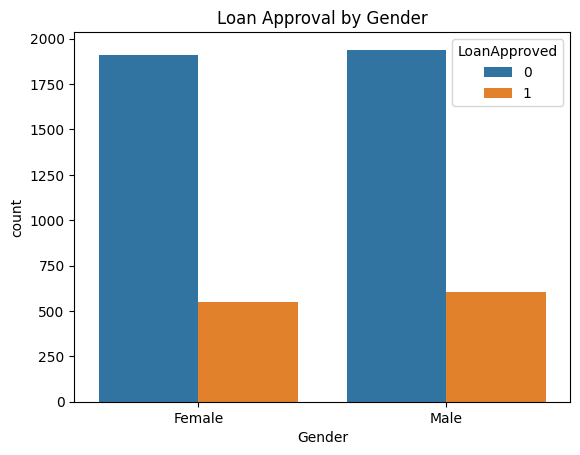

In [12]:
sns.countplot(x = df['Gender'], data = df, hue = df['LoanApproved'])
plt.title("Loan Approval by Gender")
plt.show()

This chart tells us that Gender has no remarkable effect on Loan Approval

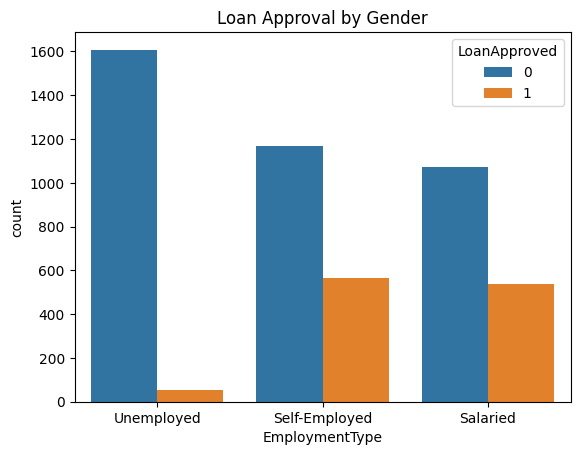

In [13]:
sns.countplot(x = df['EmploymentType'], data = df, hue = df['LoanApproved'])
plt.title("Loan Approval by Gender")
plt.show()

This chart tells us that unemployed people have a remarkably high rate of Loan rejection

In [14]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [15]:
df = df.rename(columns={'Gender': 'Is_female'})
df['Is_female'] = df['Is_female'].apply(lambda x: 1 if x == 'Female' else 0)

In [16]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Is_female,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,1,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,0,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,0,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,0,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,1,High School,Chicago,Unemployed,0


**Encoding the Features**

In [17]:
df = pd.get_dummies(df)

In [18]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Is_female,LoanApproved,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,Education_Unknown,City_Chicago,City_Houston,City_New York,City_San Francisco,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,1,0,False,True,False,False,False,False,True,False,False,False,False,True
1,69,57462.0,23262.0,586.0,6,0,0,False,True,False,False,False,False,False,False,True,False,True,False
2,46,44219.0,26530.0,781.0,26,0,1,False,False,False,True,False,False,True,False,False,False,True,False
3,32,56307.0,11531.0,549.0,11,0,0,False,False,False,False,True,False,False,True,False,False,False,True
4,60,37034.0,27871.0,500.0,19,1,0,False,True,False,False,False,True,False,False,False,False,False,True


In [19]:
df = df.astype('int')

Converting whole DataFrame to one single 'integer' data type

In [20]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Is_female,LoanApproved,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,Education_Unknown,City_Chicago,City_Houston,City_New York,City_San Francisco,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353,31258,675,20,1,0,0,1,0,0,0,0,1,0,0,0,0,1
1,69,57462,23262,586,6,0,0,0,1,0,0,0,0,0,0,1,0,1,0
2,46,44219,26530,781,26,0,1,0,0,0,1,0,0,1,0,0,0,1,0
3,32,56307,11531,549,11,0,0,0,0,0,0,1,0,0,1,0,0,0,1
4,60,37034,27871,500,19,1,0,0,1,0,0,0,1,0,0,0,0,0,1


**Creating and Evaluating Machine Learning Models**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

In [22]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [23]:
X = df.drop('LoanApproved', axis = 1)
y = df['LoanApproved']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [25]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42,class_weight="balanced"),
    'Decision Tree': DecisionTreeClassifier(random_state=42,class_weight="balanced"),
    'Random Forest': RandomForestClassifier(random_state=42,class_weight="balanced"),
    'Gradient Boost': GradientBoostingClassifier(random_state=42,),
    'Support Vector': SVC(random_state=42,class_weight="balanced")
}

In [26]:
best_model = None
best_score = -np.inf
best_model_name = None

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rocAUC = roc_auc_score(y_test, y_pred)

    print(f'{model_name}:')
    print(f'Accuracy: {accuracy:.3f}')
    print(f'F1 Score: {f1:.3f}')
    print(f'ROC-AUC: {rocAUC:.3f}')
    print('----------------------------------------')

    if rocAUC > best_score:
        best_score = rocAUC
        best_model = model
        best_model_name = model_name

print(f"Best Model: {best_model_name}")

Logistic Regression:
Accuracy: 0.753
F1 Score: 0.624
ROC-AUC: 0.801
----------------------------------------
Decision Tree:
Accuracy: 0.931
F1 Score: 0.849
ROC-AUC: 0.900
----------------------------------------
Random Forest:
Accuracy: 0.964
F1 Score: 0.919
ROC-AUC: 0.937
----------------------------------------
Gradient Boost:
Accuracy: 0.963
F1 Score: 0.917
ROC-AUC: 0.936
----------------------------------------
Support Vector:
Accuracy: 0.483
F1 Score: 0.447
ROC-AUC: 0.632
----------------------------------------
Best Model: Random Forest


**Scaling the features to improve Logistic R. and SVC models**

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42, stratify = y)

In [29]:
best_model = None
best_score = -np.inf
best_model_name = None

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rocAUC = roc_auc_score(y_test, y_pred)

    print(f'{model_name}:')
    print(f'Accuracy: {accuracy:.3f}')
    print(f'F1 Score: {f1:.3f}')
    print(f'ROC-AUC: {rocAUC:.3f}')
    print('----------------------------------------')

    if rocAUC > best_score:
        best_score = rocAUC
        best_model = model
        best_model_name = model_name

print(f"Best Model: {best_model_name}")

Logistic Regression:
Accuracy: 0.846
F1 Score: 0.728
ROC-AUC: 0.863
----------------------------------------
Decision Tree:
Accuracy: 0.932
F1 Score: 0.851
ROC-AUC: 0.901
----------------------------------------
Random Forest:
Accuracy: 0.964
F1 Score: 0.919
ROC-AUC: 0.937
----------------------------------------
Gradient Boost:
Accuracy: 0.963
F1 Score: 0.917
ROC-AUC: 0.936
----------------------------------------
Support Vector:
Accuracy: 0.882
F1 Score: 0.775
ROC-AUC: 0.882
----------------------------------------
Best Model: Random Forest
